In [1]:
print("Here begins the data overview notebook.")

Here begins the data overview notebook.


In [2]:
# Canadian Health Survey (2019-2020) – Data Overview & Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load dataset, set display options, show first few rows
pd.set_option("display.max_columns", None)

df = pd.read_csv("../../data/raw/global_mental_health_patterns/life_satisfaction_canadian_survey.csv")
df.head()

,ADM_RNO1,Province,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,Edu_level,Gen_health_state,Life_satisfaction,Mental_health_state,Stress_level,Work_stress,Sense_belonging,Weight_state,BMI_12_17,BMI_18_above,Sleep_apnea,High_BP,High_cholestrol,Diabetic,Fatigue_syndrome,Mood_disorder,Anxiety_disorder,Respiratory_chronic_con,Musculoskeletal_con,Cardiovascular_con,Health_utility_indx,Pain_status,Act_improve_health,Fruit_veg_con,Smoked,Tobaco_use,weekly_alcohol,Cannabies_use,Drug_use,Total_active_time,Total_physical_act_time,Other_physical_act_time,Physical_vigorous_act_time,Work_hours,working_status,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
0,1000,47,47906,2,1,2,3,1,3,3,9,3,2,2,2,3,6,2,2,2,2,2,2,2,2,2,2,2,1,2,6,1.3,996.0,6,996,2,2,0,0,60,10,38,1,2,1,2,1,0,1,5
1,100005,47,47906,1,1,2,5,6,2,3,4,3,3,6,3,1,6,2,1,1,2,2,2,1,2,2,2,2,9,1,6,1.0,996.0,6,996,2,2,0,0,0,0,96,6,2,1,2,1,0,2,4
2,100012,59,59914,2,2,1,5,6,1,2,7,3,3,6,2,1,6,2,2,1,2,1,2,2,2,1,1,2,1,1,6,9999.6,996.0,2,996,2,2,9996,9996,9996,9996,96,6,2,1,2,6,6,2,2
3,100015,13,13904,1,2,1,5,6,1,3,8,3,3,6,2,1,6,2,2,1,2,2,2,2,2,2,1,2,2,1,6,9999.6,996.0,6,996,2,6,9996,9996,9996,9996,96,6,2,1,2,6,0,2,3
4,100018,46,46903,1,2,1,4,2,3,5,0,5,4,6,3,3,6,2,2,1,2,9,2,2,2,9,1,9,1,2,6,9999.6,996.0,6,996,2,2,9996,9996,9996,9996,96,6,2,1,2,2,0,2,1


In [3]:
#Print information about the dataset
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

Shape: (108252, 50)

Column types:
ADM_RNO1                        int64
Province                        int64
Health_region_ grouped          int64
Gender                          int64
Marital_status                  int64
Household                       int64
Age                             int64
Worked_job_business             int64
Edu_level                       int64
Gen_health_state                int64
Life_satisfaction               int64
Mental_health_state             int64
Stress_level                    int64
Work_stress                     int64
Sense_belonging                 int64
Weight_state                    int64
BMI_12_17                       int64
BMI_18_above                    int64
Sleep_apnea                     int64
High_BP                         int64
High_cholestrol                 int64
Diabetic                        int64
Fatigue_syndrome                int64
Mood_disorder                   int64
Anxiety_disorder                int64
Respiratory_chr

In [4]:
#Print summary statistics
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ADM_RNO1,108252.0,501094.332844,288978.471309,21.0,250614.5,502202.5,751549.25,999998.0
Province,108252.0,34.405683,15.260020,10.0,24.0,35.0,47.00,60.0
Health_region_ grouped,108252.0,35330.737908,15267.165483,10911.0,24906.0,35949.0,47906.00,60901.0
Gender,108252.0,1.544729,0.497998,1.0,1.0,2.0,2.00,2.0
Marital_status,108252.0,1.748365,1.258188,1.0,1.0,1.0,2.00,9.0
Household,108252.0,1.720763,0.686516,1.0,1.0,2.0,2.00,9.0
Age,108252.0,3.825324,1.293388,1.0,3.0,4.0,5.00,5.0
Worked_job_business,108252.0,3.659489,2.460041,1.0,1.0,6.0,6.00,9.0
Edu_level,108252.0,3.001912,1.565288,1.0,3.0,3.0,3.00,9.0
Gen_health_state,108252.0,2.443770,1.064860,1.0,2.0,2.0,3.00,8.0


In [5]:
# Variable semantics, save summary to CSV
variable_summary = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique()
})

variable_summary.sort_values("missing_pct", ascending=False)
variable_summary.to_csv("../../outputs/tables/life_satisfaction_canadian_survey_variable_summary.csv", index=False)

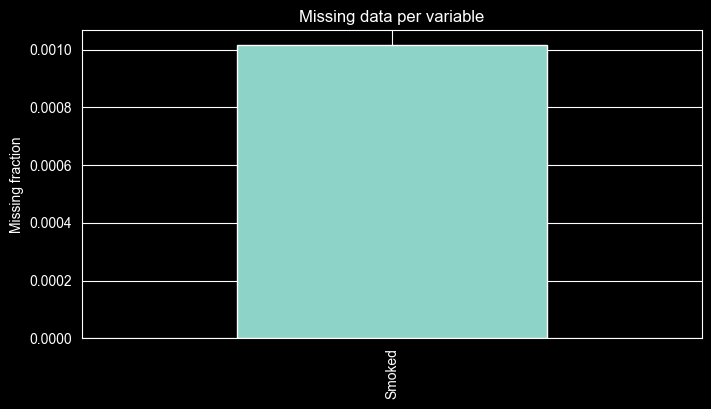

In [6]:
# Missing data analysis
missing = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
missing[missing > 0].plot(kind="bar")
plt.ylabel("Missing fraction")
plt.title("Missing data per variable")
plt.show()

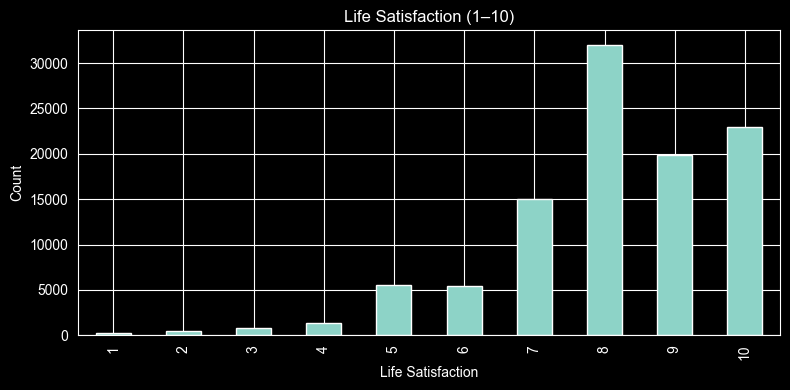

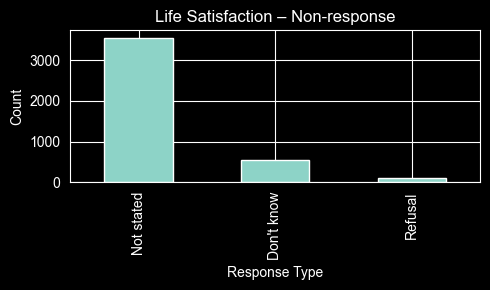

In [7]:
# Exploratory Plots
# Life Satisfaction - target variable
# Plot scale 1-10 responses
life = df["Life_satisfaction"].replace({
    97: "Don't know",
    98: "Refusal",
    99: "Not stated"
})
valid = life[life.apply(lambda x: isinstance(x, (int, float)) and 1 <= x <= 10)]
plt.figure(figsize=(8,4))
valid.value_counts().sort_index().plot(kind="bar")
plt.title("Life Satisfaction (1–10)")
plt.xlabel("Life Satisfaction")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Plot non-response categories for life satisfaction
non_response = life[life.isin(["Don't know", "Refusal", "Not stated"])]
plt.figure(figsize=(5,3))
non_response.value_counts().plot(kind="bar")
plt.title("Life Satisfaction – Non-response")
plt.xlabel("Response Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



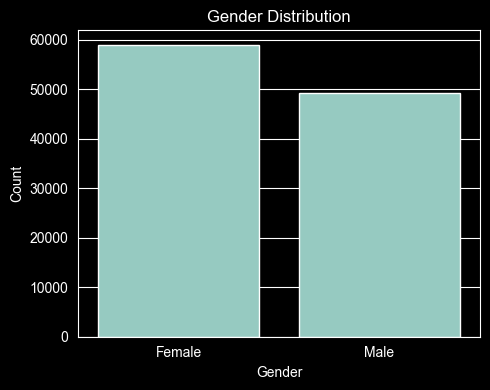

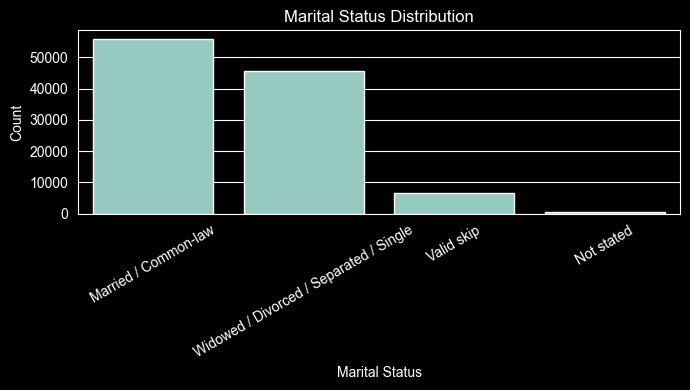

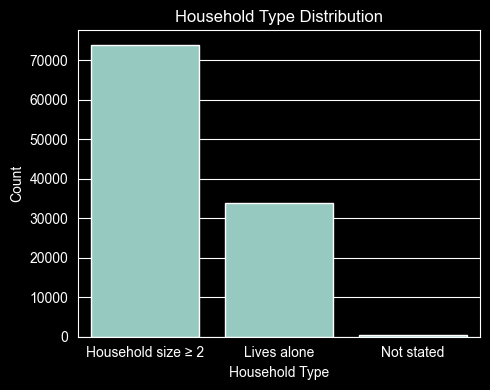

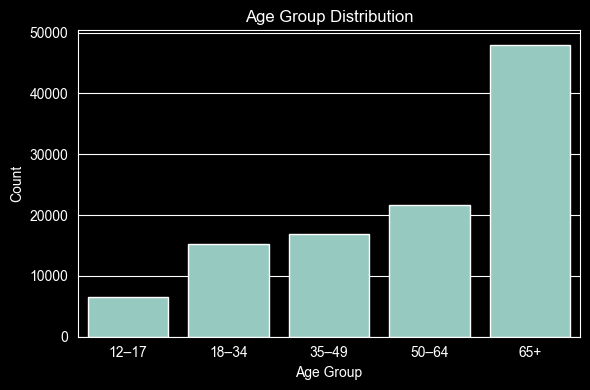

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gender distribution
df["Gender_label"] = df["Gender"].replace({
    1: "Male",
    2: "Female",
    9: "Not stated"
})

plt.figure(figsize=(5,4))
sns.countplot(x="Gender_label", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


# Marital status distribution
df["Marital_status_label"] = df["Marital_status"].replace({
    1: "Married / Common-law",
    2: "Widowed / Divorced / Separated / Single",
    6: "Valid skip",
    9: "Not stated"
})

plt.figure(figsize=(7,4))
sns.countplot(x="Marital_status_label", data=df)

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Household size
df["Household_label"] = df["Household"].replace({
    1: "Lives alone",
    2: "Household size ≥ 2",
    9: "Not stated"
})

plt.figure(figsize=(5,4))
sns.countplot(x="Household_label", data=df)

plt.title("Household Type Distribution")
plt.xlabel("Household Type")
plt.ylabel("Count")

plt.tight_layout()


# Age distribution
df["Age_group"] = df["Age"].replace({
    1: "12–17",
    2: "18–34",
    3: "35–49",
    4: "50–64",
    5: "65+"
})
age_order = ["12–17", "18–34", "35–49", "50–64", "65+"]

df["Age_group"] = pd.Categorical(
    df["Age_group"],
    categories=age_order,
    ordered=True
)
plt.figure(figsize=(6,4))
sns.countplot(x="Age_group", data=df, order=age_order)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


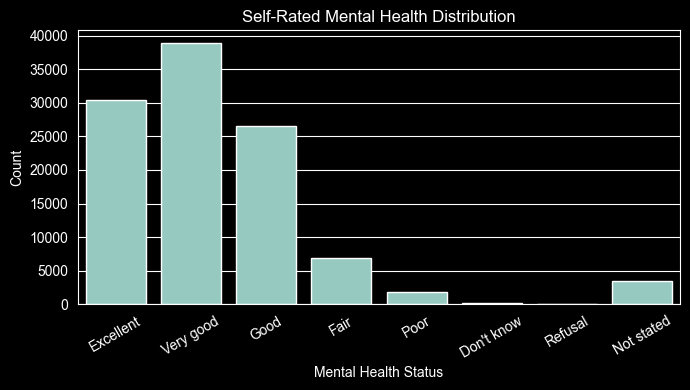

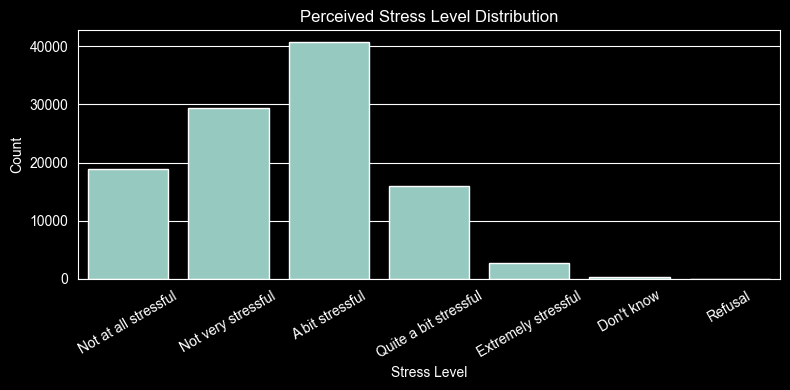

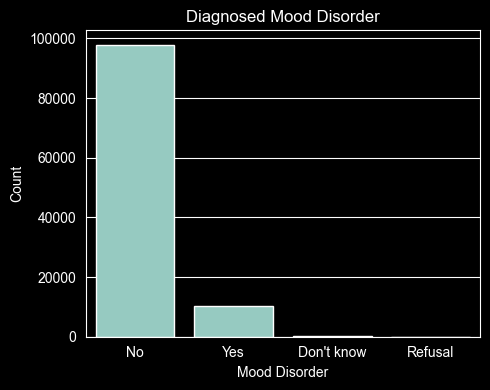

In [9]:
# Mental_health_state, Stress_level, Mood_disorder (yes/no)
df["Mental_health_label"] = df["Mental_health_state"].replace({
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor",
    7: "Don't know",
    8: "Refusal",
    9: "Not stated"
})
mental_order = [
    "Excellent",
    "Very good",
    "Good",
    "Fair",
    "Poor",
    "Don't know",
    "Refusal",
    "Not stated"
]

df["Mental_health_label"] = pd.Categorical(
    df["Mental_health_label"],
    categories=mental_order,
    ordered=True
)
plt.figure(figsize=(7,4))
sns.countplot(
    x="Mental_health_label",
    data=df,
    order=mental_order
)

plt.title("Self-Rated Mental Health Distribution")
plt.xlabel("Mental Health Status")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()




df["Stress_label"] = df["Stress_level"].replace({
    1: "Not at all stressful",
    2: "Not very stressful",
    3: "A bit stressful",
    4: "Quite a bit stressful",
    5: "Extremely stressful",
    7: "Don't know",
    8: "Refusal"
})
stress_order = [
    "Not at all stressful",
    "Not very stressful",
    "A bit stressful",
    "Quite a bit stressful",
    "Extremely stressful",
    "Don't know",
    "Refusal"
]

df["Stress_label"] = pd.Categorical(
    df["Stress_label"],
    categories=stress_order,
    ordered=True
)
plt.figure(figsize=(8,4))
sns.countplot(
    x="Stress_label",
    data=df,
    order=stress_order
)

plt.title("Perceived Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



df["Mood_disorder_label"] = df["Mood_disorder"].replace({
    1: "Yes",
    2: "No",
    7: "Don't know",
    8: "Refusal"
})
plt.figure(figsize=(5,4))
sns.countplot(x="Mood_disorder_label", data=df)

plt.title("Diagnosed Mood Disorder")
plt.xlabel("Mood Disorder")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


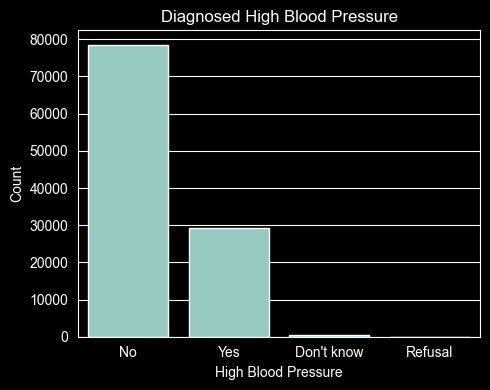

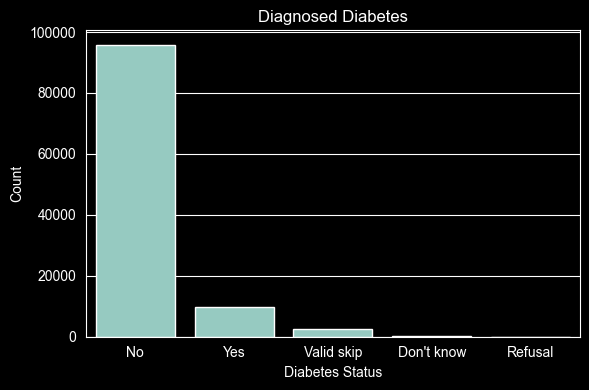

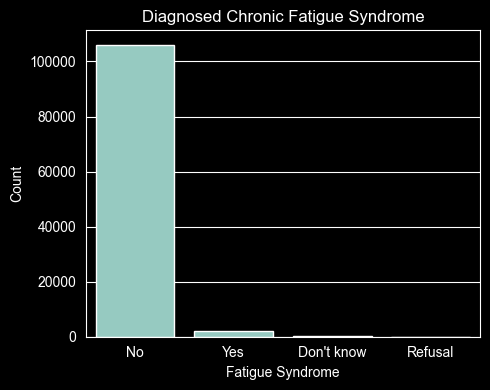

In [10]:
# High_BP, Diabetic, Fatigue_syndrome
df["High_BP_label"] = df["High_BP"].replace({
    1: "Yes",
    2: "No",
    7: "Don't know",
    8: "Refusal"
})
plt.figure(figsize=(5,4))
sns.countplot(x="High_BP_label", data=df)

plt.title("Diagnosed High Blood Pressure")
plt.xlabel("High Blood Pressure")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


df["Diabetic_label"] = df["Diabetic"].replace({
    1: "Yes",
    2: "No",
    9: "Valid skip",
    7: "Don't know",
    8: "Refusal"
})
plt.figure(figsize=(6,4))
sns.countplot(x="Diabetic_label", data=df)

plt.title("Diagnosed Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



df["Fatigue_label"] = df["Fatigue_syndrome"].replace({
    1: "Yes",
    2: "No",
    7: "Don't know",
    8: "Refusal"
})
plt.figure(figsize=(5,4))
sns.countplot(x="Fatigue_label", data=df)

plt.title("Diagnosed Chronic Fatigue Syndrome")
plt.xlabel("Fatigue Syndrome")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

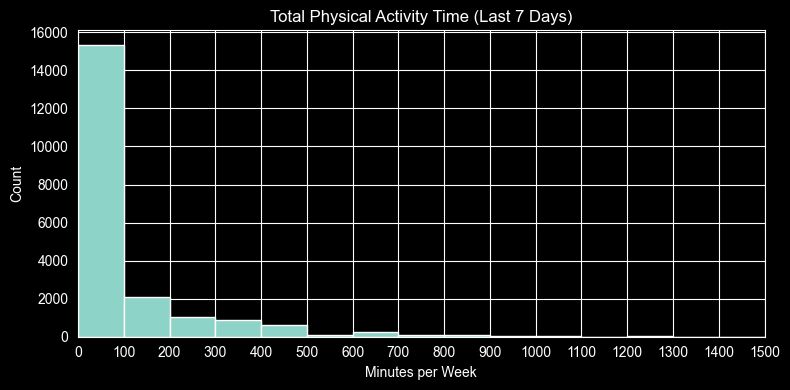

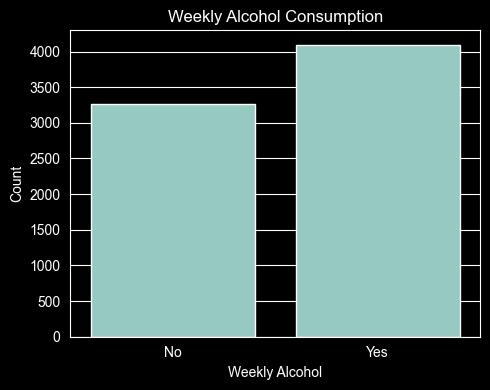

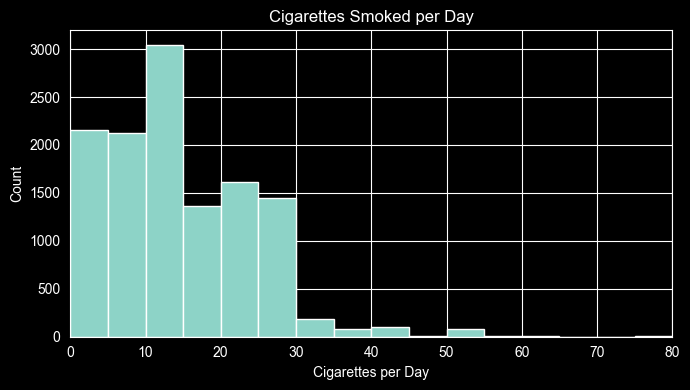

In [11]:
# Total_physical_act_time, Weekly_alcohol, Smoked
max_val = 1500

bins = np.arange(0, max_val + 100, 100)

plt.figure(figsize=(8,4))
plt.hist(df["Total_physical_act_time"].dropna(), bins=bins)

plt.title("Total Physical Activity Time (Last 7 Days)")
plt.xlabel("Minutes per Week")
plt.ylabel("Count")

plt.xlim(0, max_val)
plt.xticks(np.arange(0, max_val + 1, 100))

plt.tight_layout()
plt.show()



df["Weekly_alcohol_label"] = df["weekly_alcohol"].replace({
    1: "Yes",
    2: "No",
    6: "Valid skip",
    7: "Don't know",
    8: "Refusal",
    9: "Not stated"
})
df_valid = df[df["weekly_alcohol"].isin([1, 2])]

plt.figure(figsize=(5,4))
sns.countplot(x="Weekly_alcohol_label", data=df_valid)

plt.title("Weekly Alcohol Consumption")
plt.xlabel("Weekly Alcohol")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


df["Smoked_clean"] = df["Smoked"].replace(
    [996, 997, 998, 999],
    np.nan
)

bins = np.arange(0, 81, 5)

plt.figure(figsize=(7,4))
plt.hist(df["Smoked_clean"].dropna(), bins=bins)

plt.title("Cigarettes Smoked per Day")
plt.xlabel("Cigarettes per Day")
plt.ylabel("Count")

plt.xlim(0, 80)
plt.tight_layout()
plt.show()


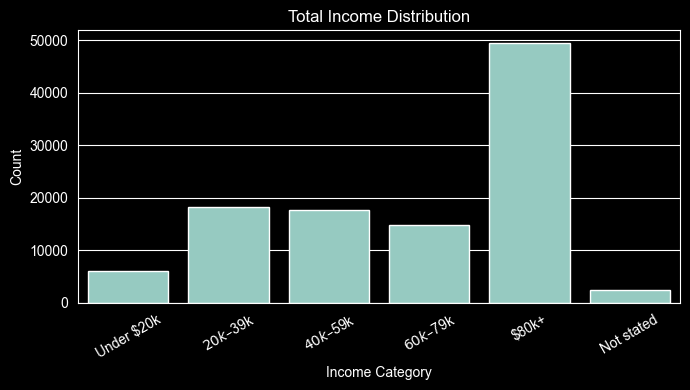

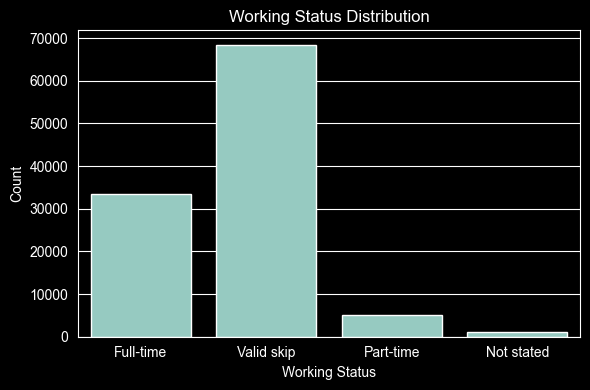

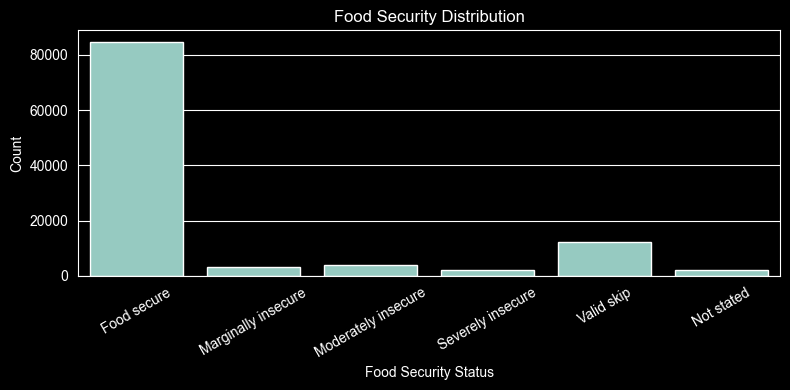

In [12]:
# Total_income, Working_status, Food_security
df["Income_label"] = df["Total_income"].replace({
    1: "Under $20k",
    2: "$20k–$39k",
    3: "$40k–$59k",
    4: "$60k–$79k",
    5: "$80k+",
    9: "Not stated"
})
income_order = [
    "Under $20k",
    "$20k–$39k",
    "$40k–$59k",
    "$60k–$79k",
    "$80k+",
    "Not stated"
]

df["Income_label"] = pd.Categorical(
    df["Income_label"],
    categories=income_order,
    ordered=True
)
plt.figure(figsize=(7,4))
sns.countplot(x="Income_label", data=df, order=income_order)

plt.title("Total Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


df["Working_status_label"] = df["working_status "].replace({
    1: "Full-time",
    2: "Part-time",
    6: "Valid skip",
    9: "Not stated"
})
plt.figure(figsize=(6,4))
sns.countplot(x="Working_status_label", data=df)

plt.title("Working Status Distribution")
plt.xlabel("Working Status")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



df["Food_security_label"] = df["Food_security"].replace({
    0: "Food secure",
    1: "Marginally insecure",
    2: "Moderately insecure",
    3: "Severely insecure",
    6: "Valid skip",
    9: "Not stated"
})
food_order = [
    "Food secure",
    "Marginally insecure",
    "Moderately insecure",
    "Severely insecure",
    "Valid skip",
    "Not stated"
]

df["Food_security_label"] = pd.Categorical(
    df["Food_security_label"],
    categories=food_order,
    ordered=True
)
plt.figure(figsize=(8,4))
sns.countplot(
    x="Food_security_label",
    data=df,
    order=food_order
)

plt.title("Food Security Distribution")
plt.xlabel("Food Security Status")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

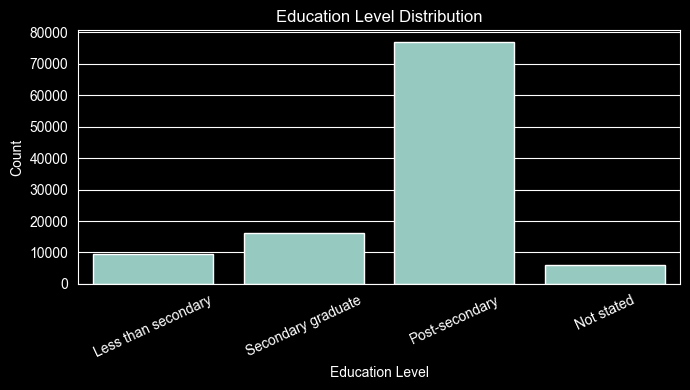

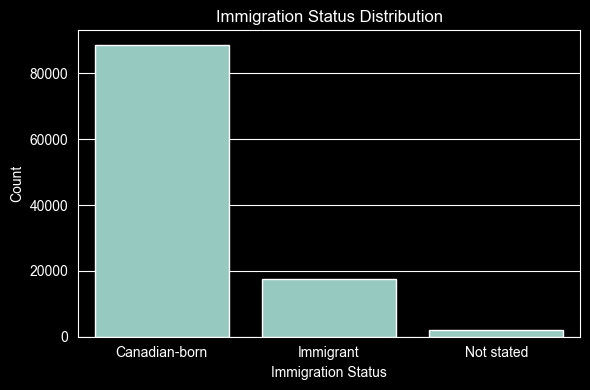

In [13]:
# Edu_level, Immigrant status
df["Edu_label"] = df["Edu_level"].replace({
    1: "Less than secondary",
    2: "Secondary graduate",
    3: "Post-secondary",
    9: "Not stated"
})
edu_order = [
    "Less than secondary",
    "Secondary graduate",
    "Post-secondary",
    "Not stated"
]

df["Edu_label"] = pd.Categorical(
    df["Edu_label"],
    categories=edu_order,
    ordered=True
)
plt.figure(figsize=(7,4))
sns.countplot(
    x="Edu_label",
    data=df,
    order=edu_order
)

plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


df["Immigrant_label"] = df["Immigrant"].replace({
    1: "Immigrant",
    2: "Canadian-born",
    9: "Not stated"
})
plt.figure(figsize=(6,4))
sns.countplot(x="Immigrant_label", data=df)

plt.title("Immigration Status Distribution")
plt.xlabel("Immigration Status")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

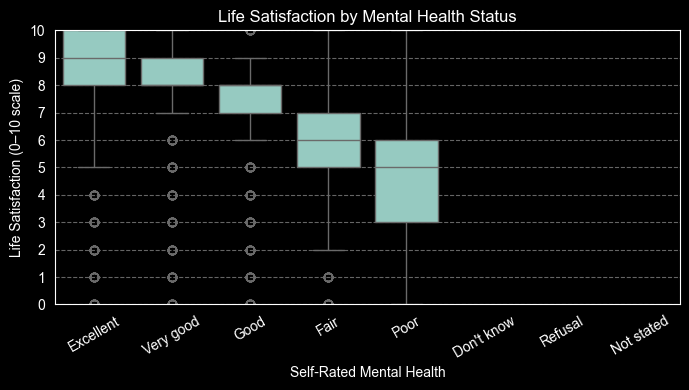

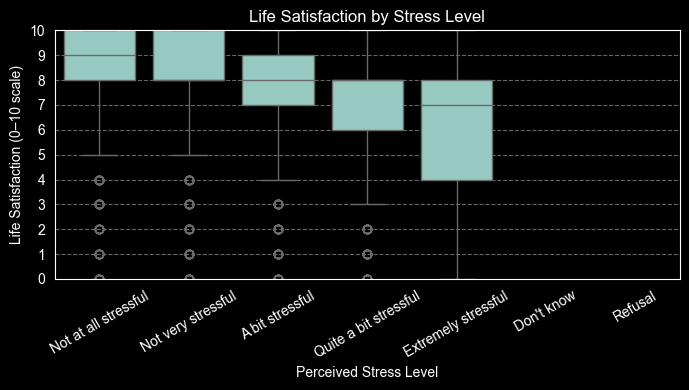

In [14]:
# Relationship with outcome
df["Life_satisfaction_clean"] = df["Life_satisfaction"].replace(
    [97, 98, 99],
    np.nan
)

valid_mh = df[df["Mental_health_state"].isin([1,2,3,4,5])]

plt.figure(figsize=(7,4))

sns.boxplot(
    x="Mental_health_label",
    y="Life_satisfaction_clean",
    data=valid_mh
)

plt.title("Life Satisfaction by Mental Health Status")
plt.xlabel("Self-Rated Mental Health")
plt.ylabel("Life Satisfaction (0–10 scale)")

plt.ylim(0, 10)
plt.yticks(range(0, 11, 1))
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()





valid_stress = df[df["Stress_level"].isin([1,2,3,4,5])]

plt.figure(figsize=(7,4))

sns.boxplot(
    x="Stress_label",
    y="Life_satisfaction_clean",
    data=valid_stress
)

plt.title("Life Satisfaction by Stress Level")
plt.xlabel("Perceived Stress Level")
plt.ylabel("Life Satisfaction (0–10 scale)")

plt.ylim(0, 10)
plt.yticks(range(0, 11, 1))
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



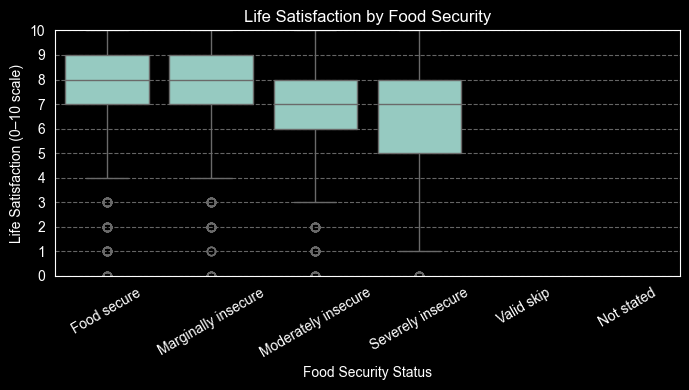

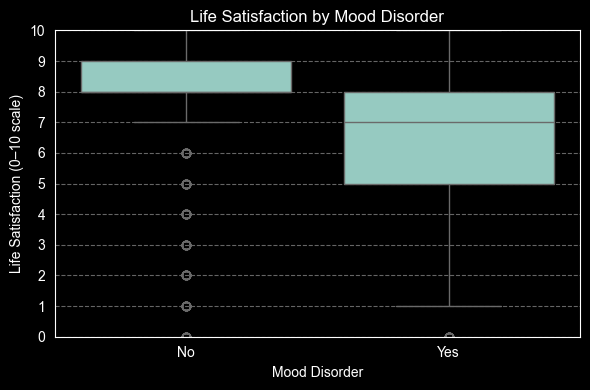

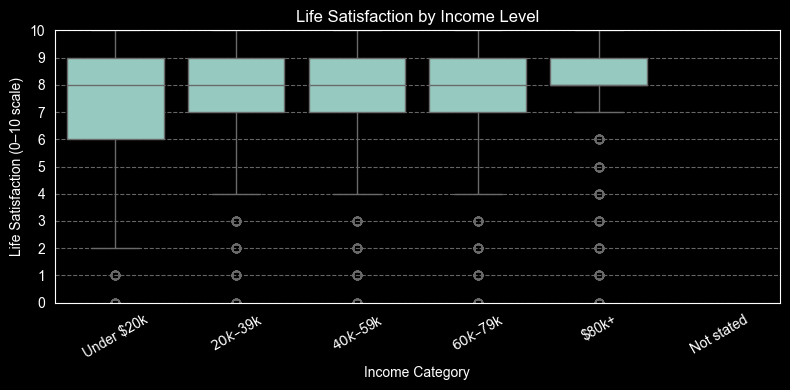

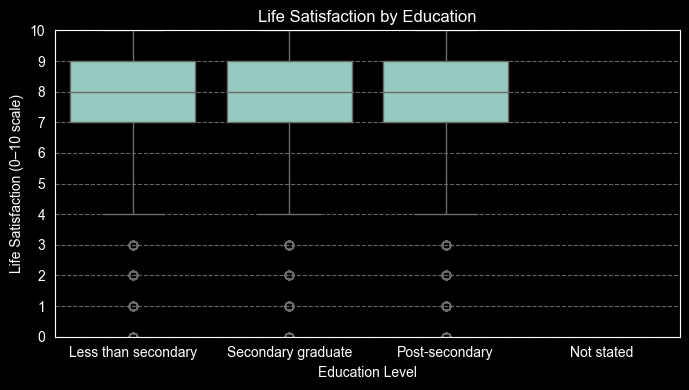

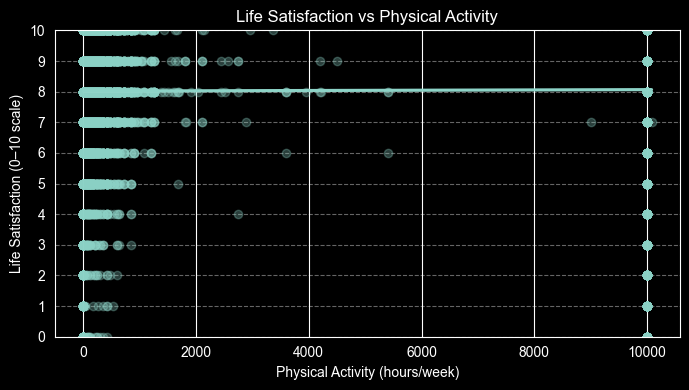

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clean outcome once
df["Life_satisfaction_clean"] = df["Life_satisfaction"].replace([97, 98, 99], np.nan)

# Helper styling for all Life Satisfaction plots
def style_ls_axis():
    plt.ylabel("Life Satisfaction (0–10 scale)")
    plt.ylim(0, 10)
    plt.yticks(range(0, 11, 1))
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

# --- Food security ---
valid_food = df[df["Food_security"].isin([0, 1, 2, 3])]

plt.figure(figsize=(7,4))
sns.boxplot(
    x="Food_security_label",
    y="Life_satisfaction_clean",
    data=valid_food
)
plt.xlabel("Food Security Status")
plt.title("Life Satisfaction by Food Security")
plt.xticks(rotation=30)
style_ls_axis()
plt.show()

# --- Mood disorder ---
valid_mood = df[df["Mood_disorder"].isin([1, 2])]

plt.figure(figsize=(6,4))
sns.boxplot(
    x="Mood_disorder_label",
    y="Life_satisfaction_clean",
    data=valid_mood
)
plt.xlabel("Mood Disorder")
plt.title("Life Satisfaction by Mood Disorder")
style_ls_axis()
plt.show()

# --- Income ---
valid_inc = df[df["Total_income"].isin([1, 2, 3, 4, 5])]

plt.figure(figsize=(8,4))
sns.boxplot(
    x="Income_label",
    y="Life_satisfaction_clean",
    data=valid_inc
)
plt.xlabel("Income Category")
plt.title("Life Satisfaction by Income Level")
plt.xticks(rotation=30)
style_ls_axis()
plt.show()

# --- Education ---
valid_edu = df[df["Edu_level"].isin([1, 2, 3])]

plt.figure(figsize=(7,4))
sns.boxplot(
    x="Edu_label",
    y="Life_satisfaction_clean",
    data=valid_edu
)
plt.xlabel("Education Level")
plt.title("Life Satisfaction by Education")
style_ls_axis()
plt.show()

# --- Physical activity (scatter + trend) ---
plt.figure(figsize=(7,4))
sns.regplot(
    x="Total_physical_act_time",
    y="Life_satisfaction_clean",
    data=df,
    scatter_kws={"alpha": 0.3}
)
plt.title("Life Satisfaction vs Physical Activity")
plt.xlabel("Physical Activity (hours/week)")
style_ls_axis()
plt.show()


In [16]:
# Preprocessing BN
import pandas as pd
import numpy as np

OUT_BN = "../../data/processed/life_satisfaction_canadian_survey_bn_clean.csv"

df = pd.read_csv("../../data/raw/global_mental_health_patterns/life_satisfaction_canadian_survey.csv")
df.columns = [c.strip() for c in df.columns]

# Drop irrelevant columns
DROP_COLS = ["ADM_RNO1", "Province"]
df_bn = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore").copy()

# Replace special survey codes with missing values
# Important: for Life_satisfaction, value 9 is a valid response and must be preserved
COMMON_MISSING_CODES = {9, 96, 97, 98, 99, 996, 997, 998, 999, 9999, 9996, 99996, 99997, 99998, 99999}
LIFE_SAT_MISSING_CODES = {96, 97, 98, 99, 996, 997, 998, 999, 9999, 9996, 99996, 99997, 99998, 99999}

for col in df_bn.columns:
    if pd.api.types.is_numeric_dtype(df_bn[col]):
        if col == "Life_satisfaction":
            df_bn[col] = df_bn[col].replace(list(LIFE_SAT_MISSING_CODES), np.nan)
        else:
            df_bn[col] = df_bn[col].replace(list(COMMON_MISSING_CODES), np.nan)

# Replace "Valid skip" with missing where applicable (only for confirmed variables)
MULTIPLE_SKIP_COLS = [
    "Worked_job_business", "Gen_health_state", "Mental_health_state", "Stress_level", "Work_stress",
    "Sense_belonging", "Weight_state", "BMI_12_17", "BMI_18_above", "Sleep_apnea", "High_BP", "High_cholesterol",
    "Diabetic", "Fatigue_syndrome", "Anxiety_disorder", "Mood_disorder", "Musculoskeletal_con", "Act_improve_health",
    "Fruit_veg_con", "Tobaco_use", "weekly_alcohol", "Cannabies_use", "working_status", "Aboriginal_identity",
    "Food_security"
]
MULTIPLE_MISSING_CODES = {6, 7, 8, 9}

for col in MULTIPLE_SKIP_COLS:
    if col in df_bn.columns:
        df_bn[col] = df_bn[col].replace(list(MULTIPLE_MISSING_CODES), np.nan)

# Replace custom missing codes for specific variables
CUSTOM_MISSING_COLS = ["Drug_use", "Birth_country", "Marital_status"]
CUSTOM_MISSING_CODES = {3, 4}

for col in CUSTOM_MISSING_COLS:
    if col in df_bn.columns:
        df_bn[col] = df_bn[col].replace(list(CUSTOM_MISSING_CODES), np.nan)

# Convert numeric-coded columns into discrete categorical states (as strings)
for col in df_bn.columns:
    s = pd.to_numeric(df_bn[col], errors="coerce")

    # If column is fully missing, keep as is
    if s.dropna().empty:
        df_bn[col] = s
        continue

    # If values are all integers, treat as encoded categorical
    if (s.dropna() % 1 == 0).all():
        df_bn[col] = s.astype("Int64").astype("string")
    else:
        # Non-integer numeric column -> discretize into bins for BN
        df_bn[col] = (
            pd.qcut(s, q=5, labels=False, duplicates="drop")
            .astype("Int64")
            .astype("string")
            .map(lambda x: f"bin_{x}" if x is not pd.NA else pd.NA)
        )

# Enforce ordinal meaning for Age (1..5)
if "Age" in df_bn.columns:
    df_bn["Age"] = pd.Categorical(
        df_bn["Age"],
        categories=["1", "2", "3", "4", "5"],
        ordered=True
    )

# Save BN dataset (keeps NaNs)
df_bn.to_csv(OUT_BN, index=False)
print("Saved BN dataset to:", OUT_BN)

# Validation for Life_satisfaction
if "Life_satisfaction" in df_bn.columns:
    print("\nLife_satisfaction distribution after cleaning:")
    print(df_bn["Life_satisfaction"].value_counts(dropna=False).sort_index())

df_bn.head()

Saved BN dataset to: ../../data/processed/life_satisfaction_canadian_survey_bn_clean.csv

Life_satisfaction distribution after cleaning:
Life_satisfaction
0         471
1         226
10      22971
2         455
3         785
4        1297
5        5566
6        5426
7       15019
8       32001
9       19835
<NA>     4200
Name: count, dtype: Int64


,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,Edu_level,Gen_health_state,Life_satisfaction,Mental_health_state,Stress_level,Work_stress,Sense_belonging,Weight_state,BMI_12_17,BMI_18_above,Sleep_apnea,High_BP,High_cholestrol,Diabetic,Fatigue_syndrome,Mood_disorder,Anxiety_disorder,Respiratory_chronic_con,Musculoskeletal_con,Cardiovascular_con,Health_utility_indx,Pain_status,Act_improve_health,Fruit_veg_con,Smoked,Tobaco_use,weekly_alcohol,Cannabies_use,Drug_use,Total_active_time,Total_physical_act_time,Other_physical_act_time,Physical_vigorous_act_time,Work_hours,working_status,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
0,47906,2,1,2,3,1,3,3,9,3,2,2,2,3,<NA>,2,2,2,2,2,2,2,2,2,2,2,1,2,<NA>,bin_0,<NA>,<NA>,<NA>,2,2,0,0,60,10,38,1,2,1,2,1,0,1,5
1,47906,1,1,2,5,<NA>,2,3,4,3,3,<NA>,3,1,<NA>,2,1,1,2,2,2,1,2,2,2,2,<NA>,1,<NA>,bin_0,<NA>,<NA>,<NA>,2,2,0,0,0,0,<NA>,<NA>,2,1,2,1,0,2,4
2,59914,2,2,1,5,<NA>,1,2,7,3,3,<NA>,2,1,<NA>,2,2,1,2,1,2,2,2,1,1,2,1,1,<NA>,bin_1,<NA>,2,<NA>,2,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,1,2,6,<NA>,2,2
3,13904,1,2,1,5,<NA>,1,3,8,3,3,<NA>,2,1,<NA>,2,2,1,2,2,2,2,2,2,1,2,2,1,<NA>,bin_1,<NA>,<NA>,<NA>,2,6,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,1,2,6,0,2,3
4,46903,1,2,1,4,2,3,5,0,5,4,<NA>,3,3,<NA>,2,2,1,2,<NA>,2,2,2,<NA>,1,<NA>,1,2,<NA>,bin_1,<NA>,<NA>,<NA>,2,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,1,2,2,0,2,1


In [17]:
df_bn.nunique().sort_values(ascending=False).head(10)

Total_active_time             211
Total_physical_act_time       208
Other_physical_act_time       202
Physical_vigorous_act_time    156
Health_region_ grouped         91
weekly_alcohol                 80
Smoked                         51
Work_hours                     50
Life_satisfaction              11
High_cholestrol                 5
dtype: int64

In [18]:
# Preprocessing ML (imputation + encoding)
import pandas as pd
import numpy as np

OUT_ML = "../../data/processed/life_satisfaction_canadian_survey_ml.csv"

def mode_impute(series: pd.Series) -> pd.Series:
    if series.dropna().empty:
        return series
    return series.fillna(series.mode(dropna=True).iloc[0])

def median_impute(series: pd.Series) -> pd.Series:
    if series.dropna().empty:
        return series
    return series.fillna(series.median())

# Start from BN-cleaned data
df_ml = df_bn.copy()

# Drop high-cardinality geographic variable
if "Health_region_grouped" in df_ml.columns:
    df_ml = df_ml.drop(columns=["Health_region_grouped"])

# Convert physical activity time variables back to numeric
TIME_COLS = [
    "Total_active_time",
    "Total_physical_act_time",
    "Other_physical_act_time",
    "Physical_vigorous_act_time",
]

for col in TIME_COLS:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors="coerce")

# Create missingness indicators
missing_indicators = []
for col in df_ml.columns:
    if df_ml[col].isna().any():
        ind_col = f"{col}__missing"
        df_ml[ind_col] = df_ml[col].isna().astype(int)
        missing_indicators.append(ind_col)

# Identify numeric vs categorical columns
num_cols = df_ml.select_dtypes(include=["number"]).columns.tolist()

# Impute numeric columns with median
for col in num_cols:
    df_ml[col] = median_impute(df_ml[col])

# Impute categorical columns with mode
cat_cols = [c for c in df_ml.columns if c not in num_cols and c not in missing_indicators]

for col in cat_cols:
    df_ml[col] = df_ml[col].astype("string")
    df_ml[col] = mode_impute(df_ml[col])

# One-hot encode categoricals
df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

# Ensure all data is numeric
df_ml = df_ml.astype(float)

# Save ML dataset
df_ml.to_csv(OUT_ML, index=False)

print("Saved ML dataset to:", OUT_ML)
df_ml.head()


Saved ML dataset to: ../../data/processed/life_satisfaction_canadian_survey_ml.csv


,Total_active_time,Total_physical_act_time,Other_physical_act_time,Physical_vigorous_act_time,Marital_status__missing,Household__missing,Worked_job_business__missing,Edu_level__missing,Gen_health_state__missing,Life_satisfaction__missing,Mental_health_state__missing,Stress_level__missing,Work_stress__missing,Sense_belonging__missing,Weight_state__missing,BMI_12_17__missing,BMI_18_above__missing,Sleep_apnea__missing,High_BP__missing,Diabetic__missing,Fatigue_syndrome__missing,Mood_disorder__missing,Anxiety_disorder__missing,Respiratory_chronic_con__missing,Musculoskeletal_con__missing,Cardiovascular_con__missing,Health_utility_indx__missing,Pain_status__missing,Act_improve_health__missing,Fruit_veg_con__missing,Smoked__missing,Tobaco_use__missing,weekly_alcohol__missing,Cannabies_use__missing,Drug_use__missing,Total_active_time__missing,Total_physical_act_time__missing,Other_physical_act_time__missing,Physical_vigorous_act_time__missing,Work_hours__missing,working_status__missing,Aboriginal_identity__missing,Birth_country__missing,Immigrant__missing,Insurance_cover__missing,Food_security__missing,Income_source__missing,Total_income__missing,Health_region_ grouped_10912,Health_region_ grouped_10913,Health_region_ grouped_11900,Health_region_ grouped_12901,Health_region_ grouped_12902,Health_region_ grouped_12903,Health_region_ grouped_12904,Health_region_ grouped_13901,Health_region_ grouped_13902,Health_region_ grouped_13903,Health_region_ grouped_13904,Health_region_ grouped_13906,Health_region_ grouped_24901,Health_region_ grouped_24902,Health_region_ grouped_24903,Health_region_ grouped_24904,Health_region_ grouped_24905,Health_region_ grouped_24906,Health_region_ grouped_24907,Health_region_ grouped_24908,Health_region_ grouped_24909,Health_region_ grouped_24911,Health_region_ grouped_24912,Health_region_ grouped_24913,Health_region_ grouped_24914,Health_region_ grouped_24915,Health_region_ grouped_24916,Health_region_ grouped_35926,Health_region_ grouped_35927,Health_region_ grouped_35930,Health_region_ grouped_35933,Health_region_ grouped_35934,Health_region_ grouped_35935,Health_region_ grouped_35936,Health_region_ grouped_35937,Health_region_ grouped_35938,Health_region_ grouped_35939,Health_region_ grouped_35940,Health_region_ grouped_35941,Health_region_ grouped_35942,Health_region_ grouped_35943,Health_region_ grouped_35944,Health_region_ grouped_35946,Health_region_ grouped_35947,Health_region_ grouped_35949,Health_region_ grouped_35951,Health_region_ grouped_35953,Health_region_ grouped_35955,Health_region_ grouped_35957,Health_region_ grouped_35958,Health_region_ grouped_35960,Health_region_ grouped_35961,Health_region_ grouped_35962,Health_region_ grouped_35965,Health_region_ grouped_35966,Health_region_ grouped_35968,Health_region_ grouped_35970,Health_region_ grouped_35975,Health_region_ grouped_35995,Health_region_ grouped_46901,Health_region_ grouped_46902,Health_region_ grouped_46903,Health_region_ grouped_46905,Health_region_ grouped_47901,Health_region_ grouped_47904,Health_region_ grouped_47905,Health_region_ grouped_47906,Health_region_ grouped_47907,Health_region_ grouped_47909,Health_region_ grouped_48931,Health_region_ grouped_48932,Health_region_ grouped_48933,Health_region_ grouped_48934,Health_region_ grouped_48935,Health_region_ grouped_59911,Health_region_ grouped_59912,Health_region_ grouped_59913,Health_region_ grouped_59914,Health_region_ grouped_59921,Health_region_ grouped_59922,Health_region_ grouped_59923,Health_region_ grouped_59931,Health_region_ grouped_59932,Health_region_ grouped_59933,Health_region_ grouped_59941,Health_region_ grouped_59942,Health_region_ grouped_59943,Health_region_ grouped_59951,Health_region_ grouped_59952,Health_region_ grouped_60901,Gender_2,Marital_status_2,Marital_status_6,Household_2,Age_2,Age_3,Age_4,Age_5,Worked_job_business_2,Edu_level_2,Edu_level_3,Gen_health_state_2,Gen_health_state_3,Gen_health_state_4,Gen_health_state_5,Life_satisfaction_1,Life_satisf